In [1]:
import pandas as pd 

# load the dataset
df = pd.read_csv(r"C:\Users\sangi\OneDrive\Desktop\spam detection project\malicious_phish.csv")

# Display the first few rows
print(df.head())


                                                 url        type
0                                   br-icloud.com.br    phishing
1                mp3raid.com/music/krizz_kaliko.html      benign
2                    bopsecrets.org/rexroth/cr/1.htm      benign
3  http://www.garage-pirenne.be/index.php?option=...  defacement
4  http://adventure-nicaragua.net/index.php?optio...  defacement


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Extract URLs and LABELS or Types
x = df['url']
y = df['type'] #categories: phishing, benign, defacement, malware

#convert text(URLs) into numerical from using TF-IDF
vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(x)

In [3]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer

# Extract URLs and labels
x = df['url']
y = df['type']  # Categories: phishing, benign, defacement, malware

# Convert text (URLs) into numerical form using TF-IDF
vectorizer = TfidfVectorizer()
x_transformed = vectorizer.fit_transform(x)

# Save the vectorizer and transformed data
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(x_transformed, 'tfidf_transformed_data.pkl')
joblib.dump(y, 'labels.pkl')  # Save labels separately if needed

print("TF-IDF model and transformed data saved successfully.")


TF-IDF model and transformed data saved successfully.


In [4]:
from sklearn.preprocessing import LabelEncoder

#convert labels into numerical values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

#mapping of labels (for reference)
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(label_mapping)


{'benign': 0, 'defacement': 1, 'malware': 2, 'phishing': 3}


In [5]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2,random_state = 42)

In [6]:
x0= x_train.shape
x1=x_test.shape
y0=y_train.shape
y1=y_test.shape
print (f"x_train={x0}, x_test={x1}, y_train={y0}, y_test={y1}")

x_train=(520952,), x_test=(130239,), y_train=(520952,), y_test=(130239,)


In [24]:
print(type(x_train))
print(x_train[:5])  # Show first few entries to check format


<class 'scipy.sparse._csr.csr_matrix'>
  (0, 2939375)	0.1682450938749055
  (0, 1406695)	0.286115110731422
  (0, 1860154)	0.19450901659124184
  (0, 1705340)	0.286115110731422
  (0, 3437606)	0.23416429571958333
  (0, 2115532)	0.286115110731422
  (0, 3437393)	0.2203537931502294
  (0, 1979427)	0.286115110731422
  (0, 3380738)	0.6489698270042454
  (0, 3646522)	0.286115110731422
  (1, 2939375)	0.15934145975535893
  (1, 2271936)	0.12500562155785988
  (1, 917361)	0.288800861390679
  (1, 1318688)	0.288800861390679
  (1, 3345413)	0.2848065890217055
  (1, 2584957)	0.288800861390679
  (1, 2312647)	0.28822623481560883
  (1, 2612374)	0.288800861390679
  (1, 3135584)	0.6146259435590173
  (1, 3637610)	0.288800861390679
  (2, 2939375)	0.1682450938749055
  (2, 1406695)	0.286115110731422
  (2, 1860154)	0.19450901659124184
  (2, 1705340)	0.286115110731422
  (2, 3437606)	0.23416429571958333
  (2, 2115532)	0.286115110731422
  (2, 3437393)	0.2203537931502294
  (2, 1979427)	0.286115110731422
  (2, 3646522)	0.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

# Ensure x_train is raw text before applying CountVectorizer
if isinstance(x_train, list) or isinstance(x_train[0], str):  
    count = CountVectorizer(max_df=0.97, max_features=4000)
    x_train_transformed = count.fit_transform(x_train)
    x_test_transformed = count.transform(x_test)
else:
    print("x_train is already vectorized. Skipping CountVectorizer.")


In [9]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import RandomizedSearchCV

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import joblib

# Load your dataset (Make sure 'url' and 'type' columns exist)
df = pd.read_csv("malicious_phish.csv")

# Extract URLs and labels
x = df['url']  # Feature (URLs)
y = df['type']  # Target (phishing, benign, defacement, malware)

# Convert URLs into numerical form using TF-IDF
vectorizer = TfidfVectorizer()
x_transformed = vectorizer.fit_transform(x)

# Split into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_transformed, y, test_size=0.2, random_state=42)

# Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

# Save the trained model and vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(model, 'url_classification_model.pkl')

print("Model and vectorizer saved successfully!")


Model and vectorizer saved successfully!


In [11]:
from sklearn.linear_model import LogisticRegression
# train the model
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import pandas as pd

# Load your dataset (Make sure 'url' and 'type' columns exist)
df = pd.read_csv("malicious_phish.csv")  

# Extract URLs and labels
X = df['url'].astype(str)  # Convert to string if not already
y = df['type']  # Target labels (phishing, benign, etc.)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a vectorizer
vectorizer = TfidfVectorizer()

# Fit on training data and transform it
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF transformation successful!")


TF-IDF transformation successful!


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import pandas as pd

# Sample dataset
df = pd.read_csv("malicious_phish.csv")  # Ensure your CSV contains a 'url' column

# Ensure URLs are strings
df['url'] = df['url'].astype(str)

# Extract features and labels
X = df['url']  # URLs as text
y = df['type']  # Labels (phishing, benign, etc.)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Apply TfidfVectorizer only on raw text data**
vectorizer = TfidfVectorizer()

# Fit and transform the training set
X_train_tfidf = vectorizer.fit_transform(X_train)  # ✅ Converts raw text to TF-IDF

# Transform the test set
X_test_tfidf = vectorizer.transform(X_test)  # ✅ Uses the same fitted vectorizer

print("TF-IDF transformation completed successfully!")


TF-IDF transformation completed successfully!


In [14]:
type(x_train)


scipy.sparse._csr.csr_matrix

In [15]:
# Skip vectorizing again if already transformed
X_train_tfidf = x_train  
X_test_tfidf = X_test  


In [16]:
print(type(x_train))


<class 'scipy.sparse._csr.csr_matrix'>


In [17]:
print(x_train[:5])  # Print the first few elements


  (0, 431807)	0.21643367852625203
  (0, 268778)	0.2503331231464975
  (0, 573401)	0.30125512854857844
  (0, 573320)	0.2836841633059079
  (0, 552052)	0.8480910524630725
  (1, 322624)	0.16201822685631345
  (1, 431807)	0.2066726269214328
  (1, 539582)	0.3687747895138418
  (1, 328404)	0.3730907284474455
  (1, 477730)	0.8098425664370245
  (2, 431807)	0.21643367852625203
  (2, 268778)	0.2503331231464975
  (2, 573401)	0.30125512854857844
  (2, 573320)	0.2836841633059079
  (2, 262391)	0.8480910524630725
  (3, 226457)	0.07694848182500476
  (3, 235751)	0.34895035621486226
  (3, 577480)	0.2861225804576583
  (3, 472018)	0.3985911896879564
  (3, 331113)	0.3457545855170271
  (3, 464413)	0.7155594168842211
  (4, 226457)	0.08663332369120315
  (4, 322611)	0.23887709558265896
  (4, 383278)	0.49618042611491564
  (4, 506770)	0.8302032192015575


In [18]:
X_train_tfidf = x_train
X_test_tfidf = X_test


In [19]:
x_train = list(map(str, x_train))  # Convert to list of strings if needed
X_train_tfidf = vectorizer.fit_transform(x_train)
X_test_tfidf = vectorizer.transform(X_test)


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a vectorizer
vectorizer = TfidfVectorizer()

# Fit on training data and transform it
X_train_tfidf = vectorizer.fit_transform(x_train)

# Transform test data
X_test_tfidf = vectorizer.transform(X_test)


In [21]:
print(type(x_train))  # Should be numpy.ndarray or scipy.sparse matrix
print(type(x_test))


<class 'list'>
<class 'scipy.sparse._csr.csr_matrix'>


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
x_train = vectorizer.fit_transform(x_train)  # Ensure text is transformed
x_test = vectorizer.transform(X_test)


In [25]:
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv("malicious_phish.csv")  
X = df['url'].astype(str)  # Ensure URLs are strings
y = df['type']  

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit vectorizer on training data only
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)  # Use the same fitted vectorizer

# Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Save the vectorizer and model
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(model, 'url_classification_model.pkl')

print("Model and vectorizer saved successfully!")

# Predict using the same vectorizer and model
y_train_pred = model.predict(X_train_tfidf)  # Corrected
y_test_pred = model.predict(X_test_tfidf)    # Corrected


Model and vectorizer saved successfully!


In [28]:
y_train_pred = model.predict(X_train_tfidf)  # Use the **same** transformed train data
y_test_pred = model.predict(X_test_tfidf)    # Use the **same** transformed test data


In [30]:
# Transform x_train and x_test before prediction
y_train_pred = model.predict(X_train_tfidf)  # ✅ Use transformed data
y_test_pred = model.predict(X_test_tfidf)    # ✅ Use transformed data

# Compute accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")


Training Accuracy: 0.9641
Testing Accuracy: 0.9498


Classification Report:
               precision    recall  f1-score   support

      benign       0.95      0.98      0.97     85778
  defacement       0.96      1.00      0.98     19104
     malware       0.99      0.95      0.97      6521
    phishing       0.90      0.75      0.82     18836

    accuracy                           0.95    130239
   macro avg       0.95      0.92      0.93    130239
weighted avg       0.95      0.95      0.95    130239



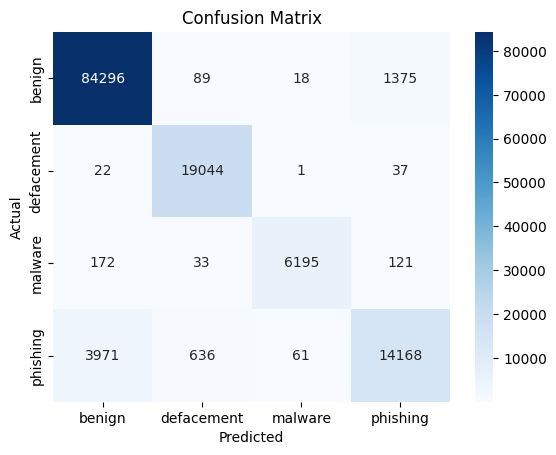

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
#generate the classification report
print("Classification Report:\n",classification_report(y_test, y_test_pred, target_names = label_encoder.classes_))

#generate the confusion matrix 
import seaborn as sns 
import matplotlib.pyplot as plt 

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot= True, fmt="d", cmap="Blues",xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
result_value={f"training_accuracy":[],"testing_accuracy":[]}
model_name=[]

In [33]:

result_value["training_accuracy"].append(train_accuracy)
result_value["testing_accuracy"].append(test_accuracy)
model_name.append("LogisticRegression")

In [34]:
result_value

{'training_accuracy': [0.9641368110689661],
 'testing_accuracy': [0.949815339491243]}

In [35]:
import joblib

# Save the model
joblib.dump(model, "linkmodel.pkl")
print("Model saved successfully!")


Model saved successfully!


In [57]:
import joblib

# Load the trained model and vectorizer
loaded_model = joblib.load('linkmodel.pkl')
loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')  # Load saved vectorizer

# Ensure x_test contains raw text before vectorization
df = pd.read_csv("malicious_phish.csv")  # Reload dataset
_, x_test_raw, _, y_test = train_test_split(df['url'], df['type'], test_size=0.2, random_state=42)  

# Transform the raw text using the loaded vectorizer
x_test_transformed = loaded_vectorizer.transform(x_test_raw)  # ✅ Use raw text

# Make predictions using the transformed test data
y_test_pred = loaded_model.predict(x_test_transformed)

# Evaluate the loaded model
from sklearn.metrics import accuracy_score
print("Loaded model test accuracy:", accuracy_score(y_test, y_test_pred))


Loaded model test accuracy: 0.949815339491243
